In [11]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import torch.nn as nn


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),                    # convert image to HxWxC tensors with floats in [0,1]
    transforms.Normalize((0.5,), (0.5,)),     # [-1, 1], cause we do (img - 0.5)/0.5 to get a centered around 0 and unit distribution
])

train_set = datasets.MNIST(
    root="./data",        
    train=True,
    download=True,
    transform=transform,
)

test_set = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=0)


In [20]:
ts=300

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device)
print(device)

cuda


In [14]:
import math
def cosine_beta(ts,s=0.008):
    """
    cosine beta schedule
    """
    steps = torch.arange(ts+1,dtype=torch.float32) #float32 (not 16) is important here for the beginning of the training
    f_t = torch.cos( (math.pi/2)*(steps/ts + s)/(1+s))**2
    print(f_t.dtype)
    alphas = f_t/f_t[0]
    return torch.clip(1 - alphas[1:]/alphas[:-1], 0 , 0.999)

In [15]:
class GaussianDiffusion(nn.Module):
    def __init__(self, model, timesteps=1000, beta_start=3.3e-4, beta_end=0.07):
        super().__init__()
        self.model = model
        self.timesteps = timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end

        # betas = torch.linspace(beta_start, beta_end, timesteps)
        betas = cosine_beta(timesteps)
        alphas = 1. - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.)

        self.register_buffer("betas",betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alphas_cumprod", alphas_cumprod)
        self.register_buffer("alphas_cumprod_prev", alphas_cumprod_prev)
        self.register_buffer("sqrt_alphas_cumprod",  torch.sqrt(alphas_cumprod))
        self.register_buffer("sqrt_one_minus_alphas_cumprod",torch.sqrt(1. - alphas_cumprod))

    
    
    def q_sampling(self, x0, t, noise):
        """ 
        Computing q(x_t | x0) for batch=b
        Cautious with dimensions!:
        x0 : b x C x H x W
        noise : x0 like 
        t : b
        """
        sqrt_alpha_t           = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)           # (B, 1, 1, 1)
        sqrt_one_minus_alpha_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1) # like ^

        x_t = sqrt_alpha_t * x0 + sqrt_one_minus_alpha_t * noise
        return x_t
    
    def p_loss(self, x0, y):
        """
        Compute the loss from x0 -> (B, *)
        """
        B, nts = x0.shape[0], self.timesteps # we need that for the time 
        t = torch.randint(nts, (B,), device=x0.device)
        noise = torch.randn_like(x0)
        x_t = self.q_sampling(x0, t, noise) 
        noise_pred = self.model(x_t, t, y)       
        loss = ((noise - noise_pred)**2).mean()
        return loss
    
    def p_sampling(self, x, t, eps):
        """
        Computing x_t-1 from eps_theta and x_t and y_t
        """
        alpha_t = self.alphas[t].view(-1, 1, 1, 1) #being careful with broadcasting
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1) #being careful with broadcasting
        beta_t = self.betas[t].view(-1, 1, 1, 1) #being careful with broadcasting
        z = torch.zeros_like(x) if t[0].item() == 0 else torch.randn_like(x)
        x_t_1 = 1/torch.sqrt(alpha_t) * (x - ((1 - alpha_t)/sqrt_one_minus_alpha_bar_t) * eps) + torch.sqrt(beta_t) * z
        return x_t_1

        

In [16]:
class Sinusembed(nn.Module):
    """
    sinusoidal embedding of time
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        """
        t -> (B,)
        """
        #device = x.device # maybe if I want to train on gpu with bigger models than mnist
        N=10000 #Attention is all you need  N**(k/(dim//2)) 
        h_dim = self.dim//2
        emb = math.log(N)/(h_dim)
        emb = torch.exp(torch.arange(h_dim) * -emb).to(device) # (h_dim,)  # I have to know when to put device or not
        emb = t[:, None] * emb[None,:] #careful with broadcast
        return torch.cat((emb.sin(), emb.cos()), dim=-1)




In [17]:
class RMSnorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.scale = dim**0.5
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))
    def forward(self,x):
        return F.normalize(x, dim=1) * self.g * self.scale #Pytorch formula normalize is the L2 and then we have the



class Resblock(nn.Module):
    def __init__(self, in_ch, out_ch, context_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        # self.norm1 = nn.GroupNorm(8, out_ch) #batch norm
        self.norm1 = RMSnorm(out_ch) #we use RMSnorm which is more efficient
        self.act1 = nn.SiLU()
        
        self.context_proj = nn.Sequential(nn.SiLU(),nn.Linear(context_dim, 2 * out_ch)) # we're doing that for the scale and shift instead of just adding the time
        # self.context_proj = nn.Linear(context_dim, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        # self.norm2 = nn.GroupNorm(8, out_ch) #batch norm
        self.norm2 = RMSnorm(out_ch)
        self.act2 = nn.SiLU()
        #res_conv = conv1x1 will be useful in upsampling
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity() #we need output and skip(x) to have the same dim
        # self.dropout = nn.Dropout(0.1) # let's see what it does
    def forward(self, x, t_emb=None):
        #block 1
        if t_emb is not None:
            t_context = self.context_proj(t_emb) #(B, 2 * out_ch)
            t_context = t_context[:,:,None,None] # We need the time_context to match output (B, 2 * out_ch, 1, 1)
            scale, shift = t_context.chunk(2, dim=1) #tuple (B, out_ch,1,1)
        
        h1 = self.conv1(x)
        h1 = self.norm1(h1)
        if t_emb is not None:
            h1 = h1 * (1 + scale) + shift #scale shift DONT FORGET TO TRY WHITHOUT SCALE adaGN
        h1 = self.act1(h1)
        #block 2
        # h1 = self.dropout(h1)
        h2 = self.conv2(h1)
        h2 = self.norm2(h2)
        h2 = self.act2(h2)
        return (h2 + self.res_conv(x)) #/np.sqrt(2) #adding variance normalisation with 1/sqrt(2)  



In [31]:
def Downsample(dima, dimb):
    return nn.Conv2d(dima, dimb, kernel_size=2, stride=2) # we divide by 2 the image feature resolution
def Upsample(dima, dimb):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode="bilinear"), #got helped by google on that one
        nn.Conv2d(dima, dimb, 3, padding=1),
    )
    

class Unet(nn.Module):
    def __init__(self,
                dim,# start dim of embedding in the Unet
                dim_mults=(2, 4),  # lets see
                channel=1,  # input channel of our images, mnist is 1
                uncond_prob=0.3,  
                classes=None,
                cond_dim=None, # dimension of the conditioning label embedding, if None we don't condition on labels
    ):
        super().__init__()
        self.uncond_prob = uncond_prob
        self.dim = dim
        self.channel = channel
        self.classes = classes
        self.cond_dim = cond_dim
        self.init_conv = nn.Conv2d(channel, dim, kernel_size=3, padding=1) #we keep the same image_size kernel=3 padd=1
        

        context_dim = dim*4 # we make the time/context embeddign big enough to be approx equal to feature embedding
        # conditioning on labels
        if self.classes is not None:
            self.label_emb = nn.Embedding(self.classes, self.cond_dim) 
            self.label_proj = nn.Sequential(nn.SiLU(), nn.Linear(self.cond_dim, context_dim), nn.SiLU(), nn.Linear(context_dim, context_dim)) 

        #getting the dimensions for ups and downs
        dims = [dim] + [dim * m for m in dim_mults]
        in_out = list(zip(dims[:-1], dims[1:])) #giving couple of (in_ch, out_ch)
        
        #timesteps encoder
        self.t_embed = nn.Sequential(Sinusembed(self.dim), nn.Linear(dim, context_dim), nn.SiLU(), nn.Linear(context_dim, context_dim))
        #ResBlocks downs
        self.downs = nn.ModuleList([])
        for (in_ch, out_ch) in in_out:
            down = nn.ModuleList([Resblock(in_ch, in_ch, context_dim), Resblock(in_ch, in_ch, context_dim), Downsample(in_ch, out_ch)])
            self.downs.append(down)
        
        #Midblocks
        mid_dim = dims[-1]
        self.mid_block1 = Resblock(mid_dim, mid_dim, context_dim)
        self.mid_block2 = Resblock(mid_dim, mid_dim, context_dim)

        # Resblock up
        self.ups = nn.ModuleList([])
        for (out_ch, in_ch) in reversed(in_out): #careful with the order in_ch, out_ch
            #we multiply by 2, cause we add the vector of the downresblocks as context
            up = nn.ModuleList([Upsample(in_ch, out_ch ),Resblock(2 * out_ch, out_ch, context_dim), Resblock(2 * out_ch, out_ch, context_dim)]) 
            self.ups.append(up)
        
        self.final_conv = nn.Conv2d(dim, channel, 1) #back to channel of the input
    
    def cfg_forward(self, x, t, y, w=1.0):
        """
        classifier-free guidance forward
        """
        x = (1+w) * self.forward(x, t, y) - w * self.forward(x, t, y=None)
        return x


    def forward(self, x, t=None, y=None):
        """
        forward of the U-net 
        """
        if t is not None:
            context_emb = self.t_embed(t)
        else:
            context_emb = None
        x = self.init_conv(x)
        
        if y is not None:
            label_embed = self.label_proj(self.label_emb(y))
            if self.training:
                mask = (torch.rand(label_embed.shape[0],device=label_embed.device) > self.uncond_prob).float() # convert to float for the model
                label_embed = mask[:, None] * label_embed # sometimes the model trains without conditioning
            context_emb = context_emb + label_embed # adding time and label conditioning by summing

        skips = []
        for down in self.downs:
            res1, res2, dsample = down
            x = res1(x, context_emb)
            skips.append(x)
            x = res2(x, context_emb)
            skips.append(x)
            x = dsample(x)
        x = self.mid_block1(x, context_emb)
        x = self.mid_block2(x, context_emb)
        for up in self.ups:
            upsample, res1, res2 = up
            x = upsample(x)
            x = torch.cat((x, skips.pop()), dim=1)
            x = res1(x, context_emb)
            x = torch.cat((x, skips.pop()), dim=1)
            x = res2(x, context_emb)
        x = self.final_conv(x)
        return x

In [32]:
# check test
# model = Unet(16, (1,2), 1, classes=10, cond_dim=16).to(device)
# x = torch.randn(4, 1, 28, 28, device=device) #SIZE OF RESOLUTION MUST MATCH THE SIZE IN DIM MULTS
# t = torch.tensor([10,500,300,50]).to(device)
# y = torch.randint(10, (4,)).to(device)
# out = model(x, t,y)
# print(out.shape, x.shape)

In [ ]:

model = torch.compile(Unet(16, (1,2), channel=1, classes=10, cond_dim=16)).to(device) #before after? speeding

from torch.utils.data import Subset, DataLoader
tiny_set = Subset(train_set, range(128)) #using the whole dataset is useless and too long to train
tiny_loader = DataLoader(tiny_set, batch_size=32, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
diff = GaussianDiffusion(model, timesteps=ts).to(device)
losses = []  
def train_loops(dataloader, diffusion, optimizer):
    diffusion.train()
    scaler = torch.cuda.amp.GradScaler() #add this to speed up a bit
    for _, (X, y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        with torch.autocast("cuda"):
            loss = diffusion.p_loss(X, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        losses.append(loss.item())


epochs = 700 
for epoch in range(epochs):
    train_loops(tiny_loader, diff, optimizer)
    if epoch % 100 == 0:
        print(f"epoch {epoch}: loss = {losses[-1]:.6f}")
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.yscale("log")  
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.show()



torch.float32


/tmp/ipython-input-33-493460588.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() #add this to speed up a bit


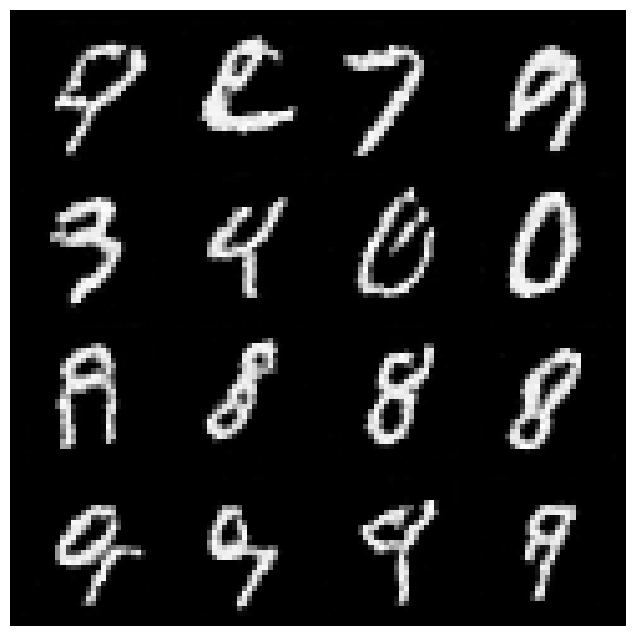

In [ ]:
import torchvision.utils as vutils

n_samples = 16

x_f = torch.randn(n_samples, 1, 28, 28, device=device)
model.eval()
y = torch.ones((n_samples,)).long().to(device) - 1
with torch.no_grad():
    for t in range( 299, -1, -1):
        t_batch = torch.full((n_samples,), t, dtype=torch.long).to(device)   
        eps = model.cfg_forward(x_f, t_batch, y, w=2)
        x_f = diff.p_sampling(x_f, t_batch, eps)
samples = ((x_f + 1) / 2).clamp(0, 1)
grid = vutils.make_grid(samples.detach().cpu(), nrow=4) #made by claude
plt.figure(figsize=(8, 8))                              #made by claude
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')  # that too
plt.axis('off')
plt.show()